# 04.4 - Supervised Learning: Komparasi dan Evaluasi Model Prediktif

**Tujuan Analisis:**
Fase ini bertujuan untuk mengevaluasi dan membandingkan keandalan hasil pelabelan dari tiga metode *clustering* sebelumnya (QLDE, Standard K-Means, dan Differential Evolution). Kita akan melihat algoritma klasifikasi mana yang paling tangguh dalam mempelajari pola dari masing-masing dataset.

**Justifikasi Pemilihan Algoritma:**
1. **Decision Tree (DT):** Dipilih karena kapabilitas interpretabilitasnya (*White-Box*). Sangat penting untuk mengekstrak Aturan Bisnis (*Business Rules*) agar dapat langsung dipahami dan diimplementasikan oleh tim *Marketing*.
2. **Support Vector Machine (KSVM):** Beroperasi sebagai *Black-Box* yang fokus pada pencarian batas optimal untuk akurasi tebakan tertinggi. (Seluruh data digunakan karena jumlah baris data masih dalam batas efisien untuk komputasi).
3. **AdaBoost:** Digunakan sebagai metode *ensemble* (kerja sama tim) untuk menutupi kelemahan model Decision Tree tunggal dan meningkatkan akurasi.
4. **Artificial Neural Network (ANN):** Otak tiruan yang diuji untuk melihat kapabilitas maksimal sistem dalam memetakan pola hubungan data yang sangat kompleks.

**Alur Eksperimental:**
Kode di bawah ini akan melakukan *training* secara otomatis terhadap seluruh dataset, melakukan validasi silang (*cross-validation*), serta mengekstrak metrik akurasi dan durasi komputasi.

In [1]:
import pandas as pd
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings

# Mengabaikan warning konvergensi ANN agar output tetap bersih
warnings.filterwarnings("ignore")

# 1. Daftar dataset yang difokuskan
file_datasets = {
    'QLDE (Paper)': '../data/Labeled/hasildata_kmeans-qlde.csv',
    'STANDARD (Baseline)': '../data/Labeled/hasildata_kmeans-standard.csv',
    'DE': '../data/Labeled/hasildata_kmeans-de.csv'
}

tabel_hasil = []

# 2. Looping ke dataset yang dipilih
for nama_metode, filepath in file_datasets.items():
    if not os.path.exists(filepath):
        print(f"File {filepath} tidak ditemukan. Lewati...")
        continue
        
    df = pd.read_csv(filepath)
    fitur = [f'Var{i}' for i in range(1, 12)]
    X = df[fitur]
    y = df['Cluster']
    
    # Membagi Data 80:20 (Menggunakan seluruh baris data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scaling seluruh data untuk algoritma yang membutuhkan standarisasi (SVM & ANN)
    scaler_full = StandardScaler()
    X_train_scaled = scaler_full.fit_transform(X_train)
    X_test_scaled = scaler_full.transform(X_test)
    
    # ==========================================
    # 1. Evaluasi Decision Tree (DT)
    # ==========================================
    model_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
    
    mulai_dt = time.time()
    val_acc_dt = cross_val_score(model_dt, X_train, y_train, cv=5).mean() * 100
    model_dt.fit(X_train, y_train)
    test_acc_dt = accuracy_score(y_test, model_dt.predict(X_test)) * 100
    selesai_dt = time.time()
    
    tabel_hasil.append({'Dataset': nama_metode, 'Method': 'Decision Tree', 
                        'Validation Accuracy (%)': round(val_acc_dt, 2), 
                        'Test Set Accuracy (%)': round(test_acc_dt, 2), 
                        'Time (sec)': round(selesai_dt - mulai_dt, 4)})
    
    # ==========================================
    # 2. Evaluasi Kernel SVM (Menggunakan 100% Data)
    # ==========================================
    model_svm = SVC(kernel='rbf', random_state=42)
    
    mulai_svm = time.time()
    val_acc_svm = cross_val_score(model_svm, X_train_scaled, y_train, cv=5).mean() * 100
    model_svm.fit(X_train_scaled, y_train)
    test_acc_svm = accuracy_score(y_test, model_svm.predict(X_test_scaled)) * 100
    selesai_svm = time.time()
    
    tabel_hasil.append({'Dataset': nama_metode, 'Method': 'SVM', 
                        'Validation Accuracy (%)': round(val_acc_svm, 2), 
                        'Test Set Accuracy (%)': round(test_acc_svm, 2), 
                        'Time (sec)': round(selesai_svm - mulai_svm, 4)})

    # ==========================================
    # 3. Evaluasi AdaBoost
    # ==========================================
    model_ada = AdaBoostClassifier(random_state=42)
    
    mulai_ada = time.time()
    val_acc_ada = cross_val_score(model_ada, X_train, y_train, cv=5).mean() * 100
    model_ada.fit(X_train, y_train)
    test_acc_ada = accuracy_score(y_test, model_ada.predict(X_test)) * 100
    selesai_ada = time.time()
    
    tabel_hasil.append({'Dataset': nama_metode, 'Method': 'AdaBoost', 
                        'Validation Accuracy (%)': round(val_acc_ada, 2), 
                        'Test Set Accuracy (%)': round(test_acc_ada, 2), 
                        'Time (sec)': round(selesai_ada - mulai_ada, 4)})

    # ==========================================
    # 4. Evaluasi Artificial Neural Network (ANN)
    # ==========================================
    model_ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    
    mulai_ann = time.time()
    val_acc_ann = cross_val_score(model_ann, X_train_scaled, y_train, cv=5).mean() * 100
    model_ann.fit(X_train_scaled, y_train)
    test_acc_ann = accuracy_score(y_test, model_ann.predict(X_test_scaled)) * 100
    selesai_ann = time.time()
    
    tabel_hasil.append({'Dataset': nama_metode, 'Method': 'ANN', 
                        'Validation Accuracy (%)': round(val_acc_ann, 2), 
                        'Test Set Accuracy (%)': round(test_acc_ann, 2), 
                        'Time (sec)': round(selesai_ann - mulai_ann, 4)})

## Hasil Komparasi Metrik
Tabel di bawah ini menampilkan rincian performa dari seluruh eksperimen. 
* **Validation Accuracy** menunjukkan seberapa stabil model saat dites berulang kali.
* **Test Set Accuracy** adalah rapor akhir model terhadap data yang belum pernah dilihat sebelumnya.
* **Time** menunjukkan berapa detik waktu yang dihabiskan algoritma untuk belajar.

In [2]:
# CETAK HASIL SEBAGAI TABEL
df_metrics = pd.DataFrame(tabel_hasil)

# Mengurutkan tabel agar rapi berdasarkan Dataset lalu Metode
df_metrics = df_metrics.sort_values(by=['Dataset', 'Method']).reset_index(drop=True)

# Menampilkan tabel
display(df_metrics)

,Dataset,Method,Validation Accuracy (%),Test Set Accuracy (%),Time (sec)
0,DE,ANN,96.71,97.12,12.8518
1,DE,AdaBoost,86.25,85.35,0.6949
2,DE,Decision Tree,85.06,84.78,0.0463
3,DE,SVM,92.16,90.20,0.3614
4,QLDE (Paper),ANN,96.48,96.77,13.1588
5,QLDE (Paper),AdaBoost,87.74,87.77,0.6947
6,QLDE (Paper),Decision Tree,82.76,82.58,0.0479
7,QLDE (Paper),SVM,89.16,89.62,0.4076
8,STANDARD (Baseline),ANN,96.86,97.92,12.6045
9,STANDARD (Baseline),AdaBoost,85.67,87.31,0.6753


## Visualisasi Hasil Komparasi
Untuk mempermudah analisis dan presentasi, kita mengubah tabel di atas menjadi grafik *Bar Chart* yang membandingkan akurasi keempat metode pada tiga dataset clustering yang berbeda.

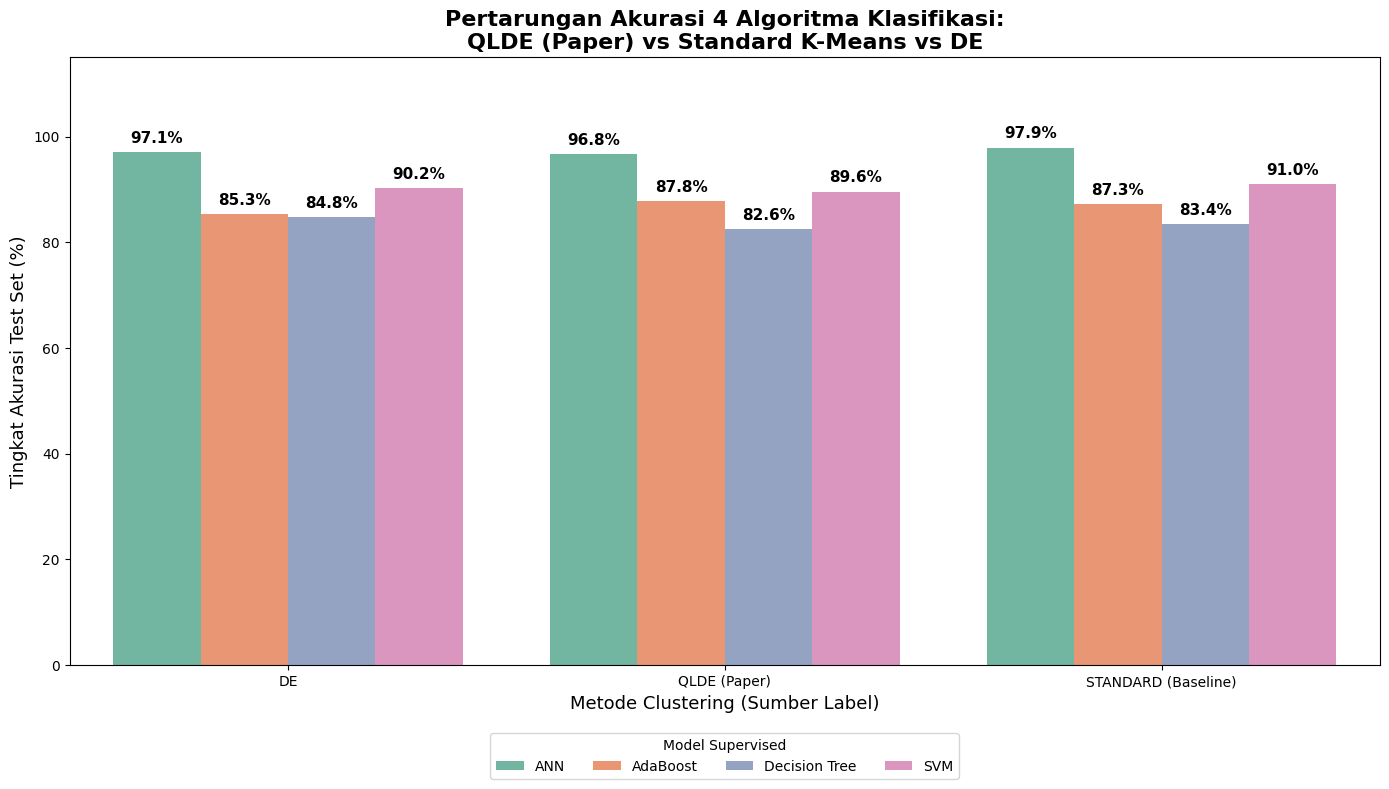

In [3]:
# VISUALISASI HASIL (Bar Chart 4 Algoritma)
plt.figure(figsize=(14, 8))

grafik = sns.barplot(
    data=df_metrics, 
    x='Dataset', 
    y='Test Set Accuracy (%)', 
    hue='Method',
    palette='Set2' # Menggunakan Set2 agar warna kontras dan profesional
)

plt.title('Pertarungan Akurasi 4 Algoritma Klasifikasi:\nQLDE (Paper) vs Standard K-Means vs DE', 
          fontsize=16, fontweight='bold')
plt.xlabel('Metode Clustering (Sumber Label)', fontsize=13)
plt.ylabel('Tingkat Akurasi Test Set (%)', fontsize=13)

# Menaikkan batas Y agar angka di atas batang tertinggi tidak terpotong
plt.ylim(0, 115) 

# Memindahkan posisi legend (keterangan warna)
plt.legend(title='Model Supervised', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

# Menampilkan angka persentase tepat di atas pucuk batang grafik
for p in grafik.patches:
    if p.get_height() > 0:
        grafik.annotate(f"{p.get_height():.1f}%", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 10), 
                       textcoords='offset points',
                       fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()